# Instron magnetometer delta

Loads the four Instron captures, subtracts each file's first valid `mz_uT` value, and plots the resulting last-column magnetometer delta against elapsed time.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


DATA_DIR = Path("Rig_tests_and_analysis")

RAW_CAPTURE_COLS = [
    "seq", "timestamp_ms",
    "ax_g", "ay_g", "az_g",
    "gx_dps", "gy_dps", "gz_dps",
    "roll_deg", "pitch_deg", "yaw_deg",
    "mx_uT", "my_uT", "mz_uT",
]

INSTRON_FILES = {
    "72 mm": "instron_1_72mm.csv",
    "72 mm + 2 mm": "instron_2_72mm_w2mm.csv",
    "100 mm": "instron3_100mm.csv",
    "50 mm": "instron4_50mm.csv",
}

MAG_DELTA_TO_R_DIFF_MM_PER_UT = 0.009659183
FORCE_QUADRATIC_A = 182.467185
FORCE_QUADRATIC_B = 398.386356


def force_n_from_mag_delta_uT(mag_delta_uT):
    r_diff_mm = MAG_DELTA_TO_R_DIFF_MM_PER_UT * mag_delta_uT.abs()
    return FORCE_QUADRATIC_A * r_diff_mm**2 + FORCE_QUADRATIC_B * r_diff_mm


def resolve_capture_path(filename):
    path = Path(filename)
    if path.exists():
        return path

    analysis_path = DATA_DIR / filename
    if analysis_path.exists():
        return analysis_path

    return path


def load_capture_csv(filename):
    path = resolve_capture_path(filename)
    rows = []
    with path.open() as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue

            parts = [part.strip() for part in line.split(",")]
            if len(parts) != len(RAW_CAPTURE_COLS):
                continue

            try:
                rows.append([float(part) for part in parts])
            except ValueError:
                continue

    if not rows:
        raise ValueError(f"No valid capture rows found in {path}")

    df = pd.DataFrame(rows, columns=RAW_CAPTURE_COLS)
    df["seq"] = df["seq"].astype(int)
    df["time_s"] = (df["timestamp_ms"] - df["timestamp_ms"].iloc[0]) / 1000.0
    df["mz_delta_uT"] = df["mz_uT"] - df["mz_uT"].iloc[0]
    df["abs_mz_delta_uT"] = df["mz_delta_uT"].abs()
    df["r_diff_mm"] = MAG_DELTA_TO_R_DIFF_MM_PER_UT * df["abs_mz_delta_uT"]
    df["force_est_n"] = force_n_from_mag_delta_uT(df["mz_delta_uT"])
    return df


captures = {label: load_capture_csv(filename) for label, filename in INSTRON_FILES.items()}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False, sharey=True)
axes = axes.ravel()
for ax, (label, df) in zip(axes, captures.items()):
    ax.plot(df["time_s"], df["mz_delta_uT"], color="tab:blue")
    ax.set_title(label)
    ax.set_xlabel("Elapsed time (s)")
    ax.set_ylabel("mz delta (uT)")
    ax.grid(True, alpha=0.3)

fig.suptitle("Instron last-column magnetometer delta over time")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False, sharey=True)
axes = axes.ravel()
for ax, (label, df) in zip(axes, captures.items()):
    ax.plot(df["time_s"], df["force_est_n"], color="tab:orange")
    ax.set_title(label)
    ax.set_xlabel("Elapsed time (s)")
    ax.set_ylabel("Estimated force (N)")
    ax.grid(True, alpha=0.3)

fig.suptitle("Magnetometer-derived force estimate using firmware calibration")
plt.tight_layout()
plt.show()

summary = pd.DataFrame(
    {
        "capture": label,
        "rows": len(df),
        "start_time_s": df["time_s"].iloc[0],
        "start_mz_delta_uT": df["mz_delta_uT"].iloc[0],
        "duration_s": df["time_s"].iloc[-1],
        "peak_abs_mz_delta_uT": df["abs_mz_delta_uT"].max(),
        "peak_r_diff_mm": df["r_diff_mm"].max(),
        "peak_force_est_n": df["force_est_n"].max(),
    }
    for label, df in captures.items()
)
summary


# Instron post-plateau force-displacement fits

Fits origin-constrained quadratic force-displacement curves after removing the plateau/contact region from `instron_1.csv` and `instron_2.csv`.

,dataset,file,raw_rows,loading_branches,cutoff_method,cutoff_displacement_mm,cutoff_force_n,fitted_points,quadratic_a,quadratic_b,r_squared
0,instron_1,instron_1.csv,3368,10,sustained >= 30.0 N,2.7144,31.0868,565,287.114949,252.284746,0.998825
1,instron_2,instron_2.csv,70,1,manual displacement cutoff,0.2140,36.0837,64,182.467185,398.386356,0.999028


,dataset,branch,cutoff_displacement_mm,cutoff_force_n
0,instron_1,1,2.7144,31.0868
1,instron_1,2,2.7384,30.9600
2,instron_1,3,2.7360,30.8054
3,instron_1,4,2.7384,30.7798
4,instron_1,5,2.7360,30.6434
5,instron_1,6,2.7360,30.1905
6,instron_1,7,2.7384,30.4644
7,instron_1,8,2.7360,30.3353
8,instron_1,9,2.7384,30.2278
9,instron_1,10,2.7600,32.3309


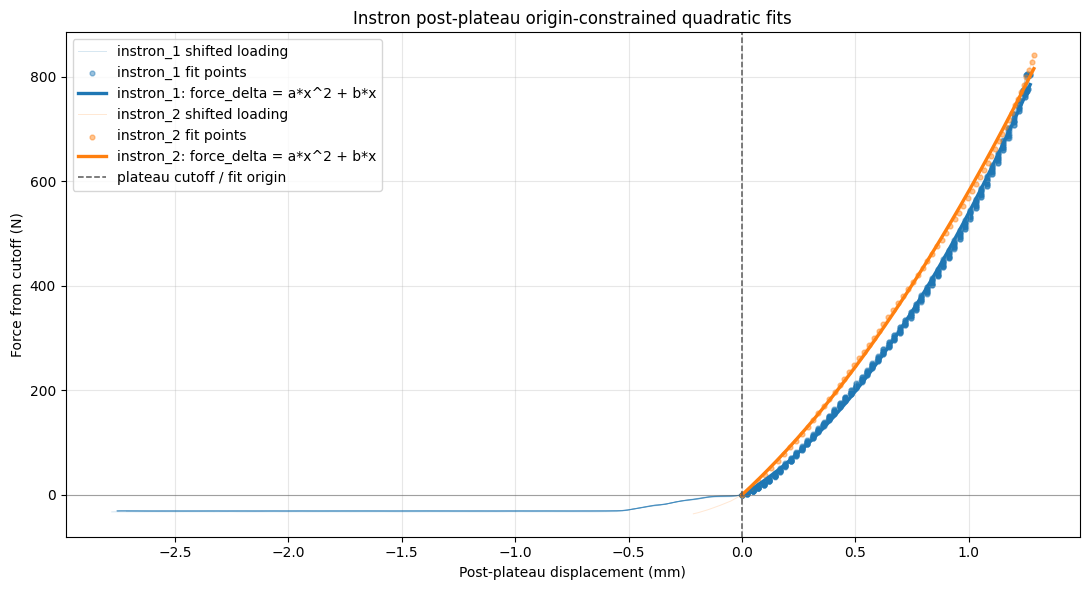

In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


FIT_CONFIGS = [
    {
        "label": "instron_1",
        "path": Path("instron_1.csv"),
        "mode": "branch_threshold",
        "threshold_n": 30.0,
        "sustained_points": 5,
    },
    {
        "label": "instron_2",
        "path": Path("instron_2.csv"),
        "mode": "manual_cutoff",
        "cutoff_displacement_mm": 0.214,
    },
]


def resolve_force_displacement_path(path):
    path = Path(path)
    if path.exists():
        return path

    analysis_path = Path("Rig_tests_and_analysis") / path.name
    if analysis_path.exists():
        return analysis_path

    return path


def load_force_displacement_csv(path):
    path = resolve_force_displacement_path(path)
    df = pd.read_csv(path, skiprows=[1], encoding="utf-8-sig")
    df = df.rename(columns={"Displacement": "displacement_mm", "Force": "force_n"})
    df = df[["displacement_mm", "force_n"]].apply(pd.to_numeric, errors="coerce").dropna()
    return df.reset_index(drop=True), path


def split_loading_branches(df):
    branches = []
    start_idx = None

    displacement = df["displacement_mm"].to_numpy()
    for idx in range(1, len(df)):
        is_increasing = displacement[idx] > displacement[idx - 1]

        if is_increasing and start_idx is None:
            start_idx = idx - 1
        elif not is_increasing and start_idx is not None:
            if idx - start_idx > 1:
                branches.append(df.iloc[start_idx:idx].copy())
            start_idx = None

    if start_idx is not None and len(df) - start_idx > 1:
        branches.append(df.iloc[start_idx:].copy())

    return branches


def first_sustained_threshold_index(force, threshold, sustained_points):
    force = np.asarray(force)
    above = force >= threshold
    run = 0
    for idx, is_above in enumerate(above):
        run = run + 1 if is_above else 0
        if run >= sustained_points:
            return idx - sustained_points + 1
    return None


def shifted_branch_fit_data(branch, cutoff_displacement, cutoff_force, branch_idx):
    shifted = branch.copy()
    shifted["branch"] = branch_idx
    shifted["post_plateau_displacement_mm"] = shifted["displacement_mm"] - cutoff_displacement
    shifted["force_delta_n"] = shifted["force_n"] - cutoff_force
    fit_points = shifted[shifted["post_plateau_displacement_mm"] >= 0].copy()
    return shifted, fit_points


def prepare_threshold_fit(raw_df, threshold_n, sustained_points):
    selected = []
    shifted_branches = []
    cutoff_rows = []
    branches = split_loading_branches(raw_df)

    for branch_idx, branch in enumerate(branches, start=1):
        cutoff_idx = first_sustained_threshold_index(branch["force_n"], threshold_n, sustained_points)
        if cutoff_idx is None:
            continue

        cutoff = branch.iloc[cutoff_idx]
        cutoff_displacement = float(cutoff["displacement_mm"])
        cutoff_force = float(cutoff["force_n"])
        shifted, fit_points = shifted_branch_fit_data(branch, cutoff_displacement, cutoff_force, branch_idx)

        cutoff_rows.append({
            "branch": branch_idx,
            "cutoff_displacement_mm": cutoff_displacement,
            "cutoff_force_n": cutoff_force,
        })
        shifted_branches.append(shifted)
        selected.append(fit_points)

    if not selected:
        return pd.DataFrame(), pd.DataFrame(cutoff_rows), pd.DataFrame(), len(branches)

    return (
        pd.concat(selected, ignore_index=True),
        pd.DataFrame(cutoff_rows),
        pd.concat(shifted_branches, ignore_index=True),
        len(branches),
    )


def prepare_manual_cutoff_fit(raw_df, cutoff_displacement):
    cutoff_force = float(np.interp(cutoff_displacement, raw_df["displacement_mm"], raw_df["force_n"]))
    shifted, fit_points = shifted_branch_fit_data(raw_df, cutoff_displacement, cutoff_force, branch_idx=1)
    cutoff_df = pd.DataFrame([{
        "branch": 1,
        "cutoff_displacement_mm": cutoff_displacement,
        "cutoff_force_n": cutoff_force,
    }])
    return fit_points, cutoff_df, shifted, 1


def fit_origin_constrained_quadratic(fit_df):
    if fit_df.empty:
        raise ValueError("No post-plateau points found for fitting")

    x = fit_df["post_plateau_displacement_mm"].to_numpy(dtype="float64")
    y = fit_df["force_delta_n"].to_numpy(dtype="float64")
    design = np.column_stack([x**2, x])
    coeffs, *_ = np.linalg.lstsq(design, y, rcond=None)
    y_pred = design @ coeffs

    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r_squared = 1.0 - ss_res / ss_tot
    return coeffs, y_pred, r_squared


results = []
summary_rows = []
cutoff_tables = []

for config in FIT_CONFIGS:
    raw_df, fit_path = load_force_displacement_csv(config["path"])

    if config["mode"] == "branch_threshold":
        fit_df, cutoff_df, shifted_df, loading_branches = prepare_threshold_fit(
            raw_df,
            threshold_n=config["threshold_n"],
            sustained_points=config["sustained_points"],
        )
        cutoff_method = f"sustained >= {config['threshold_n']} N"
    elif config["mode"] == "manual_cutoff":
        fit_df, cutoff_df, shifted_df, loading_branches = prepare_manual_cutoff_fit(
            raw_df,
            cutoff_displacement=config["cutoff_displacement_mm"],
        )
        cutoff_method = "manual displacement cutoff"
    else:
        raise ValueError(f"Unknown fit mode: {config['mode']}")

    coeffs, y_pred, r_squared = fit_origin_constrained_quadratic(fit_df)
    fit_df = fit_df.copy()
    fit_df["force_fit_delta_n"] = y_pred

    x_fit = np.linspace(0.0, fit_df["post_plateau_displacement_mm"].max(), 300)
    y_fit = coeffs[0] * x_fit**2 + coeffs[1] * x_fit

    first_cutoff = cutoff_df.iloc[0]
    summary_rows.append({
        "dataset": config["label"],
        "file": str(fit_path),
        "raw_rows": len(raw_df),
        "loading_branches": loading_branches,
        "cutoff_method": cutoff_method,
        "cutoff_displacement_mm": first_cutoff["cutoff_displacement_mm"],
        "cutoff_force_n": first_cutoff["cutoff_force_n"],
        "fitted_points": len(fit_df),
        "quadratic_a": coeffs[0],
        "quadratic_b": coeffs[1],
        "r_squared": r_squared,
    })

    labeled_cutoff_df = cutoff_df.copy()
    labeled_cutoff_df.insert(0, "dataset", config["label"])
    cutoff_tables.append(labeled_cutoff_df)

    results.append({
        "label": config["label"],
        "shifted_df": shifted_df,
        "fit_df": fit_df,
        "x_fit": x_fit,
        "y_fit": y_fit,
    })

summary_df = pd.DataFrame(summary_rows)
cutoff_df = pd.concat(cutoff_tables, ignore_index=True)
display(summary_df)
display(cutoff_df)

fig, ax = plt.subplots(figsize=(11, 6))
colors = {
    "instron_1": "tab:blue",
    "instron_2": "tab:orange",
}

for result in results:
    label = result["label"]
    color = colors.get(label, None)
    shifted_df = result["shifted_df"]
    fit_df = result["fit_df"]

    if "branch" in shifted_df.columns:
        for branch_idx, branch_df in shifted_df.groupby("branch"):
            ax.plot(
                branch_df["post_plateau_displacement_mm"],
                branch_df["force_delta_n"],
                color=color,
                alpha=0.18,
                lw=0.7,
                label=f"{label} shifted loading" if branch_idx == 1 else None,
            )

    ax.scatter(
        fit_df["post_plateau_displacement_mm"],
        fit_df["force_delta_n"],
        s=12,
        alpha=0.45,
        color=color,
        label=f"{label} fit points",
    )
    ax.plot(
        result["x_fit"],
        result["y_fit"],
        color=color,
        lw=2.4,
        label=f"{label}: force_delta = a*x^2 + b*x",
    )

ax.axvline(0.0, color="0.35", ls="--", lw=1.1, label="plateau cutoff / fit origin")
ax.axhline(0.0, color="0.35", lw=0.8, alpha=0.5)
ax.set_title("Instron post-plateau origin-constrained quadratic fits")
ax.set_xlabel("Post-plateau displacement (mm)")
ax.set_ylabel("Force from cutoff (N)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()
